# TAM -- Tópicos Avançados em Aprendizado de Máquina
## Aula 01: Exercícios

Vamos nos familiarizar com o [PyTorch](https://pytorch.org)

Para tanto, implementaremos a rede neural mais simples possível: um neurônio apenas, para resolver um problema de regressão linear

In [1]:
# Importar as bibliotecas
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# definir a arquitetura/modelo

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        # Executa a inicialização da classe pai nn.Module
        super(LinearRegressionModel, self).__init__()
        # O modelo de uma regressão linear é apenas uma camada linear
        self.linear = nn.Linear(input_dim, output_dim)

    # Processamento forward
    def forward(self, x):
        out = self.linear(x)
        return out

## 🤔 O que o `nn.Linear()` implementa?

In [3]:
# Criar dados artificiais. Dimensão da entrada=1, saída=2x+1
num_points = 30
x_values = np.random.uniform(0, 10, num_points)
x_values = np.sort(x_values).tolist()
y_values = [2*i + 1 for i in x_values]

# Adicionar ruído gaussiano, média 0 e desvio 0.5 ao y
noise = np.random.normal(0, 1, len(y_values))
y_values = [y + n for y, n in zip(y_values, noise)]

x_train = np.array(x_values, dtype=np.float32)
y_train = np.array(y_values, dtype=np.float32)

# Fazer reshape para arrays 2D (PyTorch espera entarda 2D para o nn.Linear)
x_train = x_train.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)

# Converter para tensores do PyTorch
inputs = torch.from_numpy(x_train)
targets = torch.from_numpy(y_train)

In [4]:
# Criar uma instância do modelo
input_dim = inputs.shape[1]
output_dim = targets.shape[1]
print("Input dim = %d" %input_dim)
print("Output dim = %d" %output_dim)
model = LinearRegressionModel(input_dim, output_dim)

Input dim = 1
Output dim = 1


In [5]:
# Definir a função de perda (MSE), a taxa de aprendizado (LR)
# e o otimizador (SGD)
criterion = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

## Treinamento do modelo


In [6]:
epochs = 100

for epoch in range(epochs):
    # Forward pass: compute predicted y by passing inputs to the model
    outputs = model(inputs)

    # Compute loss
    loss = criterion(outputs, targets)

    # Zero gradients, perform backward pass, and update weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 1.2976
Epoch [20/100], Loss: 1.2514
Epoch [30/100], Loss: 1.2089
Epoch [40/100], Loss: 1.1698
Epoch [50/100], Loss: 1.1338
Epoch [60/100], Loss: 1.1007
Epoch [70/100], Loss: 1.0702
Epoch [80/100], Loss: 1.0422
Epoch [90/100], Loss: 1.0164
Epoch [100/100], Loss: 0.9927


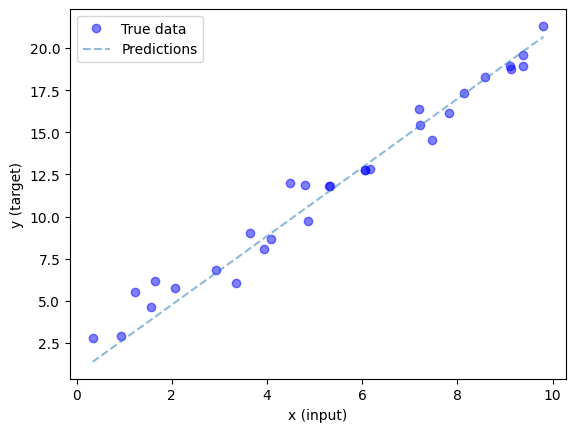

In [7]:
# Para inferência, podemos desabilitar o cálculo do gradiente
with torch.no_grad():
    predicted = model(inputs).data.numpy()

# Plotar o resultado
plt.plot(x_train, y_train, 'bo', label='True data', alpha=0.5)
plt.plot(x_train, predicted, '--', label='Predictions', alpha=0.5)
plt.xlabel('x (input)')
plt.ylabel('y (target)')
plt.legend()
plt.show()

## 🤔 Quais hiperparâmetros acima poderiam ser modificados, eventualemente? Seja do processo de geração de dados, da arquitetura do modelo, ou do treinamento.

## 🤔 Exercício

 Repetir o código acima, mas agora cconsiderando entradas de dimensão 2, na região $[0,10]\times [0,10]$ de $\mathbb{R}²$

 Copie o código acima a seguir e edite as células conforme necessidade, ou então faça uma cópia deste notebook e edite o novo notebook-cópia

In [8]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [9]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = self.linear(x)
        return out


In [10]:
num_points = 100

x1 = np.random.uniform(0, 10, num_points)
x2 = np.random.uniform(0, 10, num_points)

# Função
y = 2*x1 + 3*x2 + 1

# ruído gaussiano
noise = np.random.normal(0, 1, num_points)
y = y + noise

#  entradas
X = np.column_stack((x1, x2))

x_train = X.astype(np.float32)
y_train = y.astype(np.float32).reshape(-1, 1)

# PyTorch
inputs = torch.from_numpy(x_train)
targets = torch.from_numpy(y_train)



In [11]:
input_dim = inputs.shape[1]
output_dim = targets.shape[1]

print("Input dim = %d" % input_dim)
print("Output dim = %d" % output_dim)

model = LinearRegressionModel(input_dim, output_dim)

Input dim = 2
Output dim = 1


In [12]:
criterion = nn.MSELoss()
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [13]:
epochs = 100

for epoch in range(epochs):

    outputs = model(inputs)
    loss = criterion(outputs, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 0.8283
Epoch [20/100], Loss: 0.8112
Epoch [30/100], Loss: 0.8101
Epoch [40/100], Loss: 0.8099
Epoch [50/100], Loss: 0.8098
Epoch [60/100], Loss: 0.8097
Epoch [70/100], Loss: 0.8096
Epoch [80/100], Loss: 0.8096
Epoch [90/100], Loss: 0.8095
Epoch [100/100], Loss: 0.8094


In [14]:
with torch.no_grad():
    predicted = model(inputs).numpy()


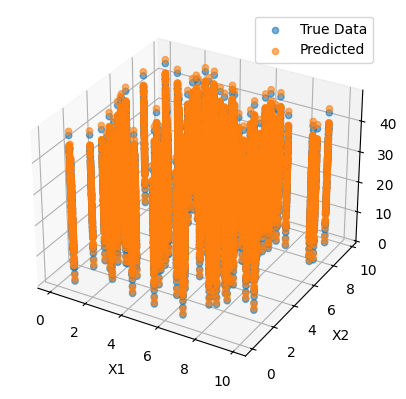

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y_train, label="True Data", alpha=0.6)
ax.scatter(x1, x2, predicted, label="Predicted", alpha=0.6)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")

plt.legend()
plt.show()
